In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import textwrap

# Расчеты конверсии

conv_i_prev - конверсия от предыдущего шага воронки\
conv_i_target - целевая конверсия на данном шаге воронки

In [2]:
data = pd.read_csv("../poll/poll_answers.csv", encoding="utf-8")

respondents = len(data)
print(f'Отправная точка опроса {respondents} респондентов')

Отправная точка опроса 60 респондентов


In [3]:
df_yes = data[data['Проводили ли вы сделки на своём брокерском счёте в последнее время?'] == 'Да']
df_no = data[data['Проводили ли вы сделки на своём брокерском счёте в последнее время?'] == 'Нет']
yes = len(df_yes)
no = len(df_no)
print(f'{len(df_yes)} респондентов, которые торгуют на бирже. Конверсию итоговую считаем от них')
print(f'{len(df_no)} респондентов, которые не торгуют на бирже. Будем использовать их для расчета побочного эффекта от продвижения опционов среди торгующих на бирже')

34 респондентов, которые торгуют на бирже. Конверсию итоговую считаем от них
26 респондентов, которые не торгуют на бирже. Будем использовать их для расчета побочного эффекта от продвижения опционов среди торгующих на бирже


In [4]:
df_trade = df_yes[df_yes['Торгуете ли вы опционами?'] == 'Да']
df_no_trade = df_yes[df_yes['Торгуете ли вы опционами?'] == 'Нет']
no_trade = len(df_no_trade)
print(f'{len(df_no_trade)} торгуют на бирже, но не торгуют опционами. Наша целевая аудитория')

24 торгуют на бирже, но не торгуют опционами. Наша целевая аудитория


                     label  value
0     Да, торгую опционами     10
1  Да, не торгую опционами     24
2  Нет, не торгую на бирже     26


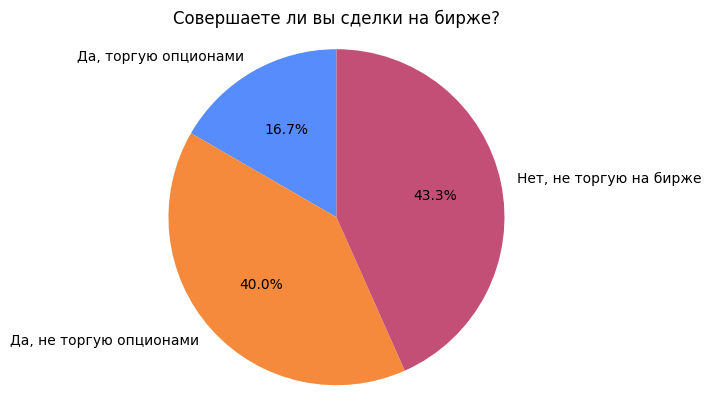

In [76]:
df = pd.DataFrame({
    "label": ["Да, торгую опционами", "Да, не торгую опционами", "Нет, не торгую на бирже"],
    "value": [len(df_trade), len(df_no_trade), len(df_no)]
})
print(df)
plt.pie(df["value"], labels=df["label"], autopct="%1.1f%%", startangle=90)
plt.title("Совершаете ли вы сделки на бирже?")
plt.axis("equal")
plt.show()

Изучаем no_trade - не торгующих опционами

In [5]:
# знание необходимой информации
df_know = df_no_trade[df_no_trade['Знакомы ли вы с такими понятиями как «временной распад стоимости опциона», «опцион в деньгах/вне денег», «страйк», «пут и колл», «греки», «улыбка волатильности»?'] == 'Да']
know = round(len(df_know) / no_trade * 100, 2)
print(f'{len(df_know)} респондентов, которые не торгуют опционами, но знакомы с базовыми понятиями')
print(f'То есть {know}% торгующих на бирже, не торгуют опционами по причинам не связанным с базовыми знаниями')

18 респондентов, которые не торгуют опционами, но знакомы с базовыми понятиями
То есть 75.0% торгующих на бирже, не торгуют опционами по причинам не связанным с базовыми знаниями


Это значит, что абсолютного непонимания природы опционов нет. Люди не торгуют ими по другим причинам

Визуализация условий начала торговли опционами среди торгующих на бирже (=основные барьеры)

In [66]:
def prepare_multi_answers_percent(series, barrier=8.0, other_label="Другое"):
    s = series
    base_n = len(s)
    if base_n == 0:
        return pd.Series(dtype=float)


    answers = (
        s.astype(str)
         .str.split(",")
         .explode()
         .str.strip()
    )
    answers = answers[answers != ""]

    counts = answers.value_counts()
    percents = counts / base_n * 100

    rare_mask = percents < barrier
    if rare_mask.any():
        rare_count = counts[rare_mask].sum()
        counts = counts[~rare_mask]

        counts[other_label] = counts.get(other_label, 0) + rare_count

    percents_final = (counts / base_n * 100).round(2).sort_values(ascending=False)
    return percents_final


def plot_barh_percents(percents, title, wrap_width=30, color=(210/255, 8/255, 8/255)):
    labels = [textwrap.fill(lbl, width=wrap_width) for lbl in percents.index[::-1]]

    plt.figure(figsize=(12, 6))
    bars = plt.barh(range(len(percents)), percents.values[::-1], color=color)
    plt.yticks(range(len(percents)), labels)
    plt.xlim(0, max(5, percents.max() + 5))
    plt.xlabel("Доля респондентов, %")
    plt.title(title)

    for bar, p in zip(bars, percents.values[::-1]):
        plt.text(bar.get_width() + 0.4, bar.get_y() + bar.get_height() / 2, f"{p}%", va="center")
    # plt.text(bars[-1].get_width() / 2, bars[0].get_y() +  bars[-1].get_height() / 2, f"От {len(percents)} опрошенных")
    plt.tight_layout()
    plt.show()


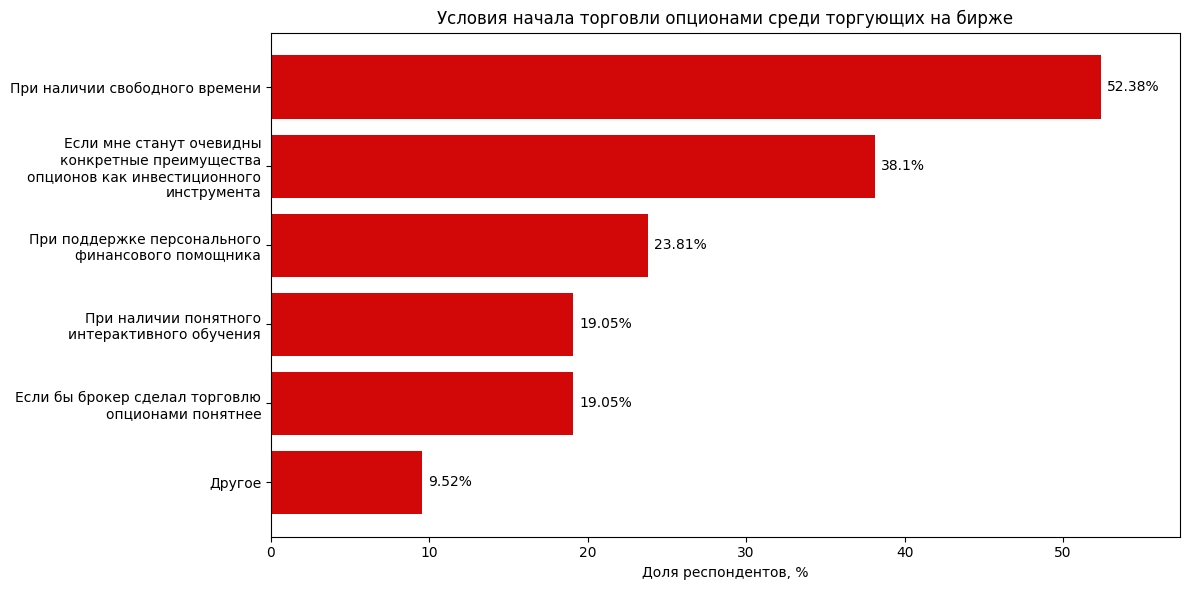

In [67]:
question_for_no_trade = "При каких условиях вы бы скорее всего начали торговать опционами? "
percents_for_no_trade = prepare_multi_answers_percent(df_no_trade[question_for_no_trade].dropna())
plot_barh_percents(percents_for_no_trade, "Условия начала торговли опционами среди торгующих на бирже")


Визуализация условий начала торговли опционами среди не торгующих на бирже (=основные барьеры с другой перспективы)

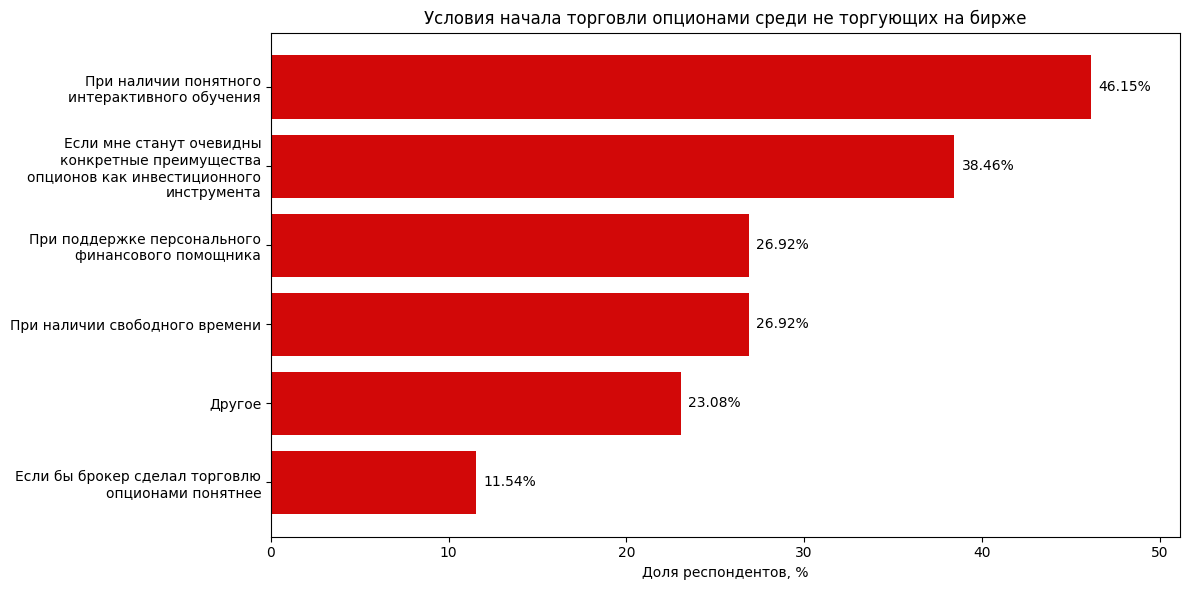

In [68]:
question_for_no = "При каких условиях вы бы скорее всего начали торговать опционами? "
percents_for_no = prepare_multi_answers_percent(df_no[question_for_no].dropna())
plot_barh_percents(percents_for_no, "Условия начала торговли опционами среди не торгующих на бирже")


Визуализация условий начала торговли опционами среди не торгующих на бирже (=основные барьеры с другой перспективы)

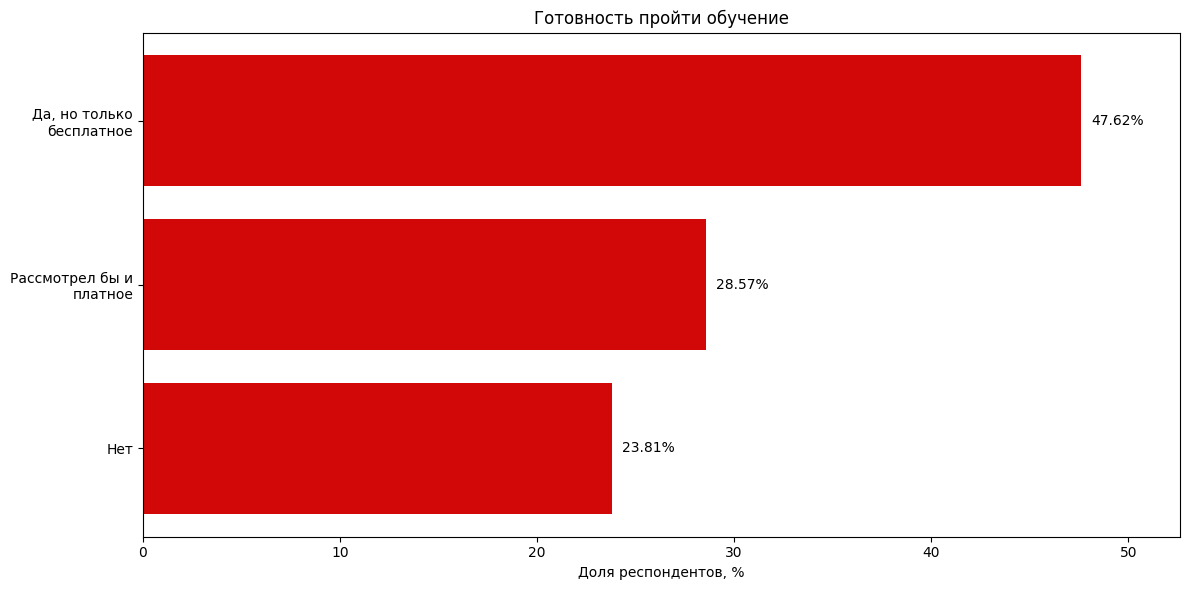

In [8]:
# визуализация готовности пройти обучение
question = 'Готовы ли вы пройти обучение для старта торговли опционами в ближайшее время, если найдёте подходящий каталог курсов от Московской биржи?'
s = df_no_trade[question].dropna()
answers = s
# answers = (
#     s.astype(str)
#      .str.split(",")
#      .explode()
#      .str.strip()
# )

answers = answers[answers != ""]

counts = answers.value_counts()
percents = (counts / len(s) * 100).round(2)

# labels = [lbl for lbl in percents.index[::-1]]
order = ['Да, но только бесплатное', 'Рассмотрел бы и платное', 'Нет']
labels = [textwrap.fill(lbl, width=15) for lbl in order[::-1]]
plt.figure(figsize=(12, 6))
bars = plt.barh(range(len(percents)), percents.values[::-1], color=(210/255, 8/255, 8/255))
plt.yticks(range(len(percents)), labels)
plt.xlim(0, percents.max() + 5)
plt.xlabel("Доля респондентов, %")
plt.title("Готовность пройти обучение")

for bar, p in zip(bars, percents.values[::-1]):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f"{p}%", va="center")

plt.tight_layout()
plt.show()

In [9]:
question = 'Готовы ли вы пройти обучение для старта торговли опционами в ближайшее время, если найдёте подходящий каталог курсов от Московской биржи?'
df_ready_to_study = df_no_trade[(df_no_trade[question] == 'Да, но только бесплатное') | (df_no_trade[question] == 'Рассмотрел бы и платное')]
conv_1_prev = round(len(df_ready_to_study) / no_trade * 100, 2)
conv_1_target = round(len(df_ready_to_study) / no_trade * 100, 2)
print(f'{len(df_no_trade)} Готовы пройти обучение')
print(f'1 уровень воронки: Конверсия от предыдущего шага составила {conv_1_prev}%')
print(f'1 уровень воронки: Конверсия целевая составила {conv_1_target}%')

24 Готовы пройти обучение
1 уровень воронки: Конверсия от предыдущего шага составила 62.5%
1 уровень воронки: Конверсия целевая составила 62.5%


In [10]:
question = 'Если бы в приложении брокера (или в любом брокерском приложении, которым вы могли бы воспользоваться) появилась «песочница» для торговли опционами — виртуальный счёт с реальными котировками и полным функционалом — насколько вероятно, что вы начали бы с ней работать в ближайшие 6 месяцев?'
df_ready_sandbox = df_ready_to_study[df_ready_to_study[question].between(5, 10)]
conv_2_prev = round(len(df_ready_sandbox) / len(df_ready_to_study) * 100, 2)
conv_2_target = round(len(df_ready_sandbox) / no_trade * 100, 2)
print(f'{len(df_ready_sandbox)} Готовы поторговать в песочнице')
print(f'2 шаг воронки: Конверсия от предыдущего шага составила {conv_2_prev}%')
print(f'2 шаг воронки: Конверсия целевая составила {conv_2_target}%')

11 Готовы поторговать в песочнице
2 шаг воронки: Конверсия от предыдущего шага составила 73.33%
2 шаг воронки: Конверсия целевая составила 45.83%


In [11]:
question = "Если бы после освоения «песочницы» вы почувствовали уверенность в своих действиях, насколько вероятно, что вы перешли бы к реальной торговле опционами?"
df_after_sandbox = df_ready_sandbox[df_ready_sandbox[question].between(5, 10)]
conv_3_prev = round(len(df_after_sandbox) / len(df_ready_sandbox) * 100, 2)
conv_3_target = round(len(df_after_sandbox) / no_trade * 100, 2)
print(f'{len(df_after_sandbox)} Готовы поторговать на реальном счете')
print(f'3 шаг воронки: Конверсия от предыдущего шага составила {conv_3_prev}%')
print(f'3 шаг воронки: Конверсия целевая составила {conv_3_target}%')
conversion_pre_final = conv_3_target

11 Готовы поторговать на реальном счете
3 шаг воронки: Конверсия от предыдущего шага составила 100.0%
3 шаг воронки: Конверсия целевая составила 45.83%


In [12]:
# учитываем тех, кто не торгует на бирже, для побочного эффекта продуктово-маркетинговой компании
investors_mm = 25.1
ru_population_mm = 146
investing_koeff = investors_mm / ru_population_mm
investors_potential = investing_koeff * no
result_of_growth_of_investors = (investors_potential + yes) / yes

# всего потенциальных торгующих опционами после кампании

conversion_final = result_of_growth_of_investors * conversion_pre_final
print(f'Итоговая конверсия модельная равна {round(conversion_final, 2)}%')

Итоговая конверсия модельная равна 51.86%


# Ограничение и сценарный подход
Стоит отметить, что данный результат конверсии после перехода на образовательную платформу является чересчур оптимистичным. Ограничением нашего анализа является смещенная выборка. Поскольку мы разбираемся в срочном рынке, люди в нашем кругу общения более вероятно сделают цепочку целевых действий по сравнению со среднестатистическим россиянином. Так как распространяли опросы мы преимущественно через своих знакомых и знакомых своих знакомых, важно сделать поправку на это в конверсии. Мы оценили эффект переоценки конверсии в 10%, поэтому на каждом шаге воронки результат будет умножаться на 0.9. Также необходимо учесть прочие риски, но об этом чуть позже.\
Всего у нас 3 шага воронки после попадания человека на образовательную платформу (при переходе по ссылке наших маркетинговых партнеров), поэтому конверсия в оптимистичном сценарии составляет:

In [13]:
corr_coef_optimistic = 0.9
optimistic_conversion = conversion_final * (corr_coef_optimistic ** 3)
print(round(optimistic_conversion, 2))

37.8


Также мы выделили 2 основных риска нашего анализа, исходя из которых мы уточняем полученный результат в трех сценариях:
* Сценарий Пессимистичный: в дополнение к смещенной выборке, мы потенциально имеем: 1) нечестные и недобросовестные ответы, 2) потенциально меньшую конверсию из-за спектра прочих факторов, которые мы не можем предсказать. За каждый из рисков убираем 10% на каждом шаге воронки (домножаем конверсию на 0.7 на каждом шаге)
* Сценарий Базовый: 1) нечестные и недобросовестные ответы. Конечно, мы старались распространить опрос среди надежных людей, но проконтролировать качество респондентов не представлялось возможным, поскольку была сделана ставка на максимизацию количества опрошенных (домножаем на 0.8 на каждом шаге)
* Сценарий Оптимистичный: отсутствие вышеупомянутых рисков

In [14]:
corr_coeff_base = 0.8
base_conversion = conversion_final * (corr_coeff_base ** 3)
corr_coeff_pessimistic = 0.7
pessimistic_conversion = conversion_final * (corr_coeff_pessimistic ** 3)
print(f'Пессимистичная {round(pessimistic_conversion, 2)}%')
print(f'Базовая {round(base_conversion, 2)}%')
print(f'Позитивная {round(optimistic_conversion, 2)}%')

Пессимистичная 17.79%
Базовая 26.55%
Позитивная 37.8%
